In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Config
model_name = "albert-base-v2"
num_labels = len(class_names)
max_length = 128
batch_size = 32
epochs = 3
lr = 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

model.dropout.p = 0.2

model.to(device)

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist() if hasattr(texts, "tolist") else list(texts)
        self.labels = labels.tolist() if hasattr(labels, "tolist") else list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# # Oversample training data to match the majority class size
train_df = pd.DataFrame({
    "tweet_clean": X_train.values,
    "class": y_train.values
})

max_count = train_df["class"].value_counts().max()

balanced_parts = []
for cls, grp in train_df.groupby("class"):
    balanced_parts.append(
        grp.sample(n=max_count, replace=True, random_state=42)
    )

train_balanced_df = (
    pd.concat(balanced_parts, axis=0)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X_train_balanced = train_balanced_df["tweet_clean"]
y_train_balanced = train_balanced_df["class"].astype(int)

print("Class distribution after oversampling:")
print(y_train_balanced.value_counts().sort_index())

train_ds = TweetDataset(X_train_balanced, y_train_balanced, tokenizer, max_length=max_length)
val_ds = TweetDataset(X_val, y_val, tokenizer, max_length=max_length)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


history = {
    'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
    'val_loss': [], 'val_acc': [], 'val_macro_f1': []
}

for epoch in range(epochs):
    # ---- Train ----
    model.train()
    
    train_loss_total = 0
    train_correct = 0
    train_total = 0

    train_preds, train_labels = [], []

    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        out = model(**batch)
        loss = out.loss
        loss.backward()
        optimizer.step()

        # Track metrics
        train_loss_total += loss.item()
        preds = torch.argmax(out.logits, dim=-1)
        labels = batch["labels"]
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        train_loss_total += loss.item()

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        # Progress update every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | "
                    f"Loss: {loss.item():.4f}")

    avg_train_loss = train_loss_total / len(train_loader)
    train_acc = train_correct / train_total
    train_macro_f1 = f1_score(train_labels, train_preds, average="macro")

    # ---- Validate ----
    model.eval()
    val_loss_total = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            labels = batch["labels"].to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            out = model(**batch)
            val_loss_total += out.loss.item()

            preds = torch.argmax(out.logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss_total / len(val_loader)
    val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
    val_macro_f1 = f1_score(val_labels, val_preds, average="macro")

    # Store history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['train_macro_f1'].append(train_macro_f1)
    history['val_macro_f1'].append(val_macro_f1)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Macro F1: {train_macro_f1:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )

Using device: cuda


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class distribution after oversampling:
class
0    13433
1    13433
2    13433
Name: count, dtype: int64
  Epoch 1 | Batch 50/1260 | Loss: 0.9078
  Epoch 1 | Batch 100/1260 | Loss: 0.7613
  Epoch 1 | Batch 150/1260 | Loss: 0.5285
  Epoch 1 | Batch 200/1260 | Loss: 0.3674
  Epoch 1 | Batch 250/1260 | Loss: 0.4774
  Epoch 1 | Batch 300/1260 | Loss: 0.5958
  Epoch 1 | Batch 350/1260 | Loss: 0.3818
  Epoch 1 | Batch 400/1260 | Loss: 0.3092
  Epoch 1 | Batch 450/1260 | Loss: 0.4934
  Epoch 1 | Batch 500/1260 | Loss: 0.3216
  Epoch 1 | Batch 550/1260 | Loss: 0.2660
  Epoch 1 | Batch 600/1260 | Loss: 0.2574
  Epoch 1 | Batch 650/1260 | Loss: 0.2247
  Epoch 1 | Batch 700/1260 | Loss: 0.1850
  Epoch 1 | Batch 750/1260 | Loss: 0.3375
  Epoch 1 | Batch 800/1260 | Loss: 0.3488
  Epoch 1 | Batch 850/1260 | Loss: 0.2164
  Epoch 1 | Batch 900/1260 | Loss: 0.2195
  Epoch 1 | Batch 950/1260 | Loss: 0.3900
  Epoch 1 | Batch 1000/1260 | Loss: 0.1589
  Epoch 1 | Batch 1050/1260 | Loss: 0.2820
  Epoch 1 | B

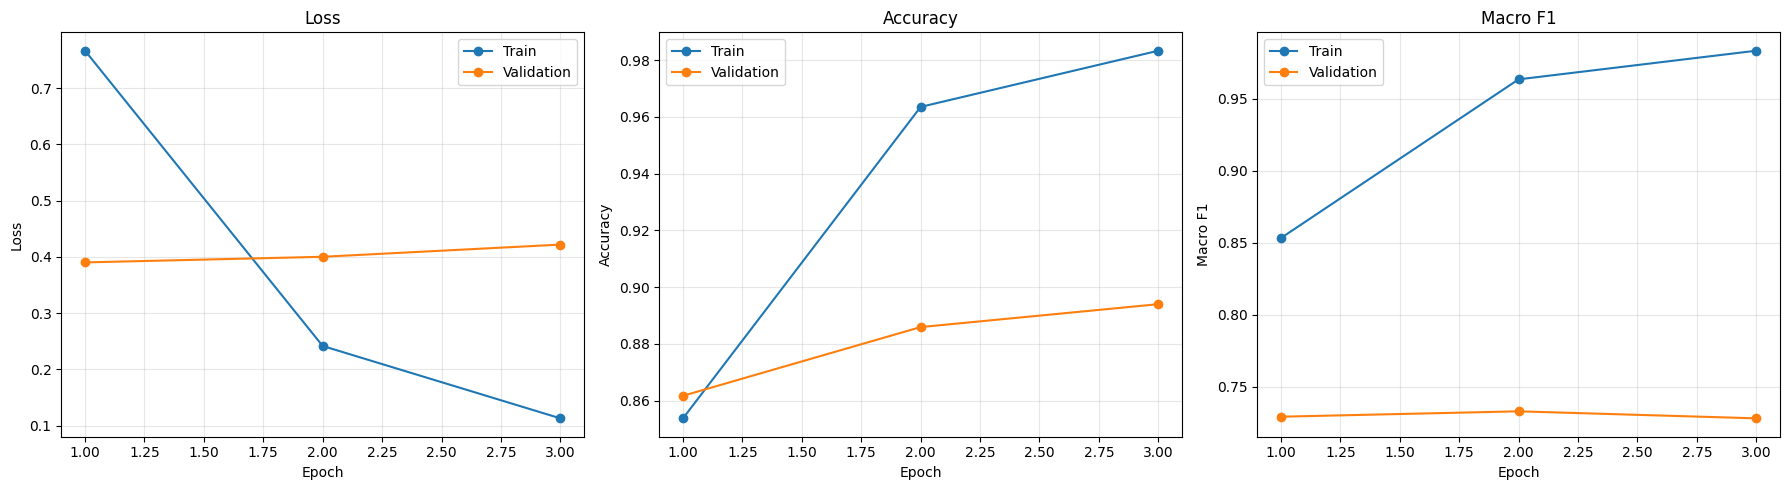

Test Accuracy: 0.8975
Test Macro F1: 0.7304

Classification Report:
                    precision    recall  f1-score   support

       hate_speech     0.3938    0.3551    0.3735       214
offensive_language     0.9342    0.9423    0.9383      2879
           neither     0.8824    0.8768    0.8796       625

          accuracy                         0.8975      3718
         macro avg     0.7368    0.7248    0.7304      3718
      weighted avg     0.8944    0.8975    0.8959      3718



In [6]:

history_df = pd.DataFrame(history)
epochs_range = range(1, len(history_df) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history_df["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_range, history_df["val_loss"], marker="o", label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_df["train_acc"], marker="o", label="Train")
axes[1].plot(epochs_range, history_df["val_acc"], marker="o", label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history_df["train_macro_f1"], marker="o", label="Train")
axes[2].plot(epochs_range, history_df["val_macro_f1"], marker="o", label="Validation")
axes[2].set_title("Macro F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro F1")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test set
test_ds = TweetDataset(X_test, y_test, tokenizer, max_length=max_length)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

test_preds, test_labels = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].to(device)
        batch = {k: v.to(device) for k, v in batch.items()}

        out = model(**batch)
        preds = torch.argmax(out.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
test_macro_f1 = f1_score(test_labels, test_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

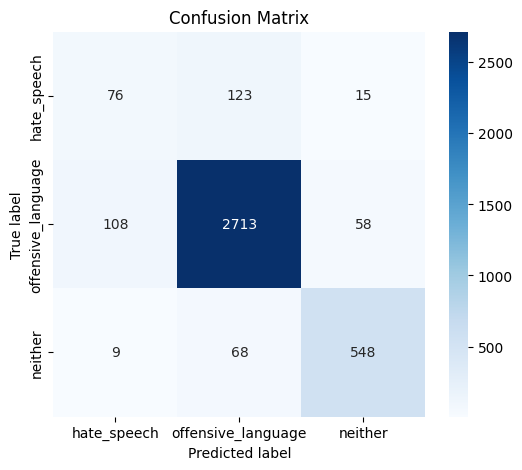

In [8]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [9]:
# Misclassified examples
misclassified_indices = np.where(np.array(test_preds) != np.array(test_labels))[0]
misclassified_df = pd.DataFrame({
    "tweet": X_test.iloc[misclassified_indices].values,
    "true_label": [class_names[i] for i in np.array(test_labels)[misclassified_indices]],
    "predicted_label": [class_names[i] for i in np.array(test_preds)[misclassified_indices]]
})

print("\nMisclassified Examples:")
display(misclassified_df.head(10))


Misclassified Examples:


,tweet,true_label,predicted_label
0,hi ho,neither,offensive_language
1,lets go hoosiers iubb,neither,offensive_language
2,rt half of it will be about how you became ghe...,offensive_language,neither
3,delete now you bitch ass nigga rt if the redsk...,hate_speech,offensive_language
4,aww y u so mad tho a successful man lmfao hut ...,hate_speech,offensive_language
5,rt todays horoscope you re still a hoe that is...,neither,offensive_language
6,rt rt for every bad bitch there is a nigga who...,hate_speech,offensive_language
7,hoes thnk they won when the nigga thats ridin ...,hate_speech,offensive_language
8,they already have are you retarded,offensive_language,hate_speech
9,rt not just cause of hoes go to jail cause of ...,hate_speech,offensive_language
